# Estimated Haplotype Post Analysis

- See if log likelihood converged to the right haplotype frequency
- See if the estimated haplotype frequencies are close to the true haplotype frequencies throughout all samples
- See if the estimated haplotypes exist in the true haplotypes, wrongly estimated haplotypes that are not in the true haplotype set, and haplotypes that weren't estimated but existed in the true haplotypes. Shows the relationship between haplotypes and an MST.

In [4]:
# Parameters
true_haplotypes = "true_haplotypes.csv"
estimation_count = 6

In [5]:
import re
import plotly.graph_objects as go
import numpy as np
from pathlib import Path
from typing import Optional, Tuple


def parse_hm_log(log_path: str) -> Tuple[list[float], list[Tuple[int, int]]]:
    """
    Parse a haplmate log file to extract total costs and SA start positions.
    
    Args:
        log_path: Path to the log file
        
    Returns:
        Tuple of (costs, sa_starts) where:
        - costs: List of total cost values in order
        - sa_starts: List of (iteration_index, n_haplotypes) tuples marking SA starts
    """
    # Regex to strip ANSI escape codes
    ansi_escape = re.compile(r'\x1b\[[0-9;]*m')
    
    # Patterns to match
    sa_start_pattern = re.compile(r'Running SA with (\d+) haplotypes, iteration (\d+)')
    total_cost_pattern = re.compile(r'Total cost: ([\d.]+)')
    
    costs = []
    sa_starts = []  # (iteration_index, n_haplotypes)
    
    with open(log_path, 'r') as f:
        for line in f:
            # Strip ANSI codes
            clean_line = ansi_escape.sub('', line)
            
            # Check for SA start
            sa_match = sa_start_pattern.search(clean_line)
            if sa_match:
                n_haplotypes = int(sa_match.group(1))
                # The SA start occurs at the current cost count (before adding new costs)
                sa_starts.append((len(costs), n_haplotypes))
                continue
            
            # Check for total cost
            cost_match = total_cost_pattern.search(clean_line)
            if cost_match:
                costs.append(float(cost_match.group(1)))
    
    return costs, sa_starts


def minmax_downsample(x: np.ndarray, y: np.ndarray, max_points: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Downsample data using min-max method to preserve visual shape.
    
    For each bucket, keeps the min and max values to preserve peaks and valleys.
    This gives 2 points per bucket, maintaining the visual appearance of the data.
    """
    n = len(x)
    if n <= max_points:
        return x, y
    
    # Number of buckets (each bucket produces 2 points: min and max)
    n_buckets = max_points // 2
    bucket_size = n / n_buckets
    
    x_downsampled = []
    y_downsampled = []
    
    for i in range(n_buckets):
        start_idx = int(i * bucket_size)
        end_idx = int((i + 1) * bucket_size)
        
        if start_idx >= n:
            break
            
        end_idx = min(end_idx, n)
        bucket_y = y[start_idx:end_idx]
        bucket_x = x[start_idx:end_idx]
        
        if len(bucket_y) == 0:
            continue
        
        # Find min and max indices within this bucket
        min_idx = np.argmin(bucket_y)
        max_idx = np.argmax(bucket_y)
        
        # Add in order of x value to maintain line continuity
        if min_idx <= max_idx:
            x_downsampled.extend([bucket_x[min_idx], bucket_x[max_idx]])
            y_downsampled.extend([bucket_y[min_idx], bucket_y[max_idx]])
        else:
            x_downsampled.extend([bucket_x[max_idx], bucket_x[min_idx]])
            y_downsampled.extend([bucket_y[max_idx], bucket_y[min_idx]])
    
    return np.array(x_downsampled), np.array(y_downsampled)


def plot_optimization_progress(
    hm_log: str,
    title: Optional[str] = None,
    height: int = 600,
    width: int = 1200,
    max_points: int = 5000,
) -> go.Figure:
    """
    Plot the optimization progress from a haplmate log file (interactive).
    
    Args:
        hm_log: Path to the log file
        title: Optional title for the plot. Defaults to the log filename.
        height: Figure height in pixels
        width: Figure width in pixels
        max_points: Maximum number of points to display (downsamples if exceeded).
                   Uses min-max downsampling to preserve visual shape.
                   Set to None to disable downsampling.
        
    Returns:
        Plotly Figure object (interactive - use mouse to zoom, pan, hover)
    """
    log_path = Path(hm_log)
    costs, sa_starts = parse_hm_log(hm_log)
    
    if not costs:
        print("No cost data found in log file!")
        return None
    
    iterations = np.arange(len(costs))
    costs_arr = np.array(costs)
    
    # Downsample if needed
    if max_points is not None and len(costs) > max_points:
        print(f"Downsampling {len(costs):,} points to ~{max_points:,} for performance...")
        x_plot, y_plot = minmax_downsample(iterations, costs_arr, max_points)
    else:
        x_plot, y_plot = iterations, costs_arr
    
    # Create figure
    fig = go.Figure()
    
    # Add total cost trace
    fig.add_trace(go.Scattergl(
        x=x_plot,
        y=y_plot,
        mode='lines',
        name='Total cost',
        line=dict(color='#1f77b4', width=1),
        hovertemplate='Iteration: %{x:,.0f}<br>Cost: %{y:,.2f}<extra></extra>'
    ))
    
    # Add vertical lines for SA starts
    y_min = float(costs_arr.min())
    y_max = float(costs_arr.max())
    
    for i, (sa_iter, n_haplotypes) in enumerate(sa_starts):
        label = f'SA start (n={n_haplotypes})' if i == 0 else f'n={n_haplotypes}'
        fig.add_trace(go.Scatter(
            x=[sa_iter, sa_iter],
            y=[y_min, y_max],
            mode='lines',
            name=label,
            line=dict(color='red', width=1, dash='dash'),
            hovertemplate=f'{label}<br>Iteration: {sa_iter:,}<extra></extra>'
        ))
    
    # Update layout
    fig.update_layout(
        title=title or log_path.name,
        xaxis_title='Iteration',
        yaxis_title='Total cost',
        height=height,
        width=width,
        hovermode='closest',
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="right",
            x=0.99
        ),
        # Enable range slider for easy navigation
        xaxis=dict(
            rangeslider=dict(visible=True),
            type='linear'
        )
    )
    
    # Configure zoom/pan behavior
    fig.update_xaxes(fixedrange=False)
    fig.update_yaxes(fixedrange=False)
    
    return fig


Downsampling 312,669 points to ~10,000 for performance...


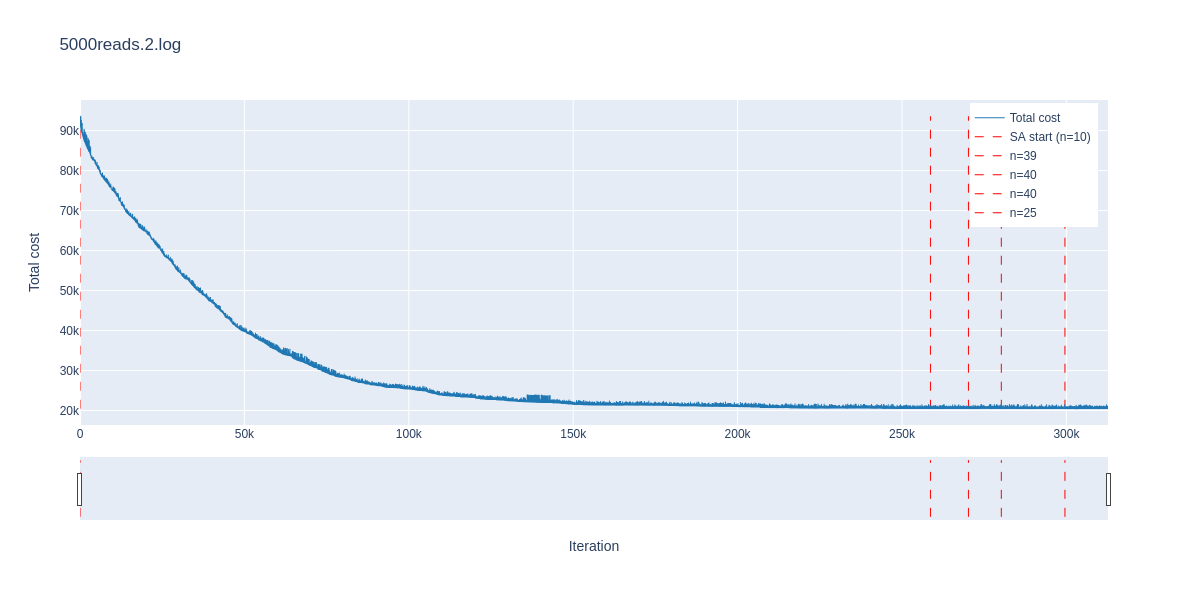

In [8]:
# Example usage:
# Returns an interactive Plotly figure - use mouse to:
#   - Zoom: Click and drag to select a region, or use scroll wheel
#   - Pan: Hold shift + drag, or use the pan tool in the toolbar
#   - Reset: Double-click to reset view
#   - Range slider: Use the slider at the bottom for quick navigation

# Default: downsamples to 5000 points for smooth interaction
fig = plot_optimization_progress("5000reads.2.log")
fig.show()

# For more detail (but may be slower): increase max_points
# fig = plot_optimization_progress("5000reads.2.log", max_points=10000)

# To show all points (may crash on large files):
# fig = plot_optimization_progress("5000reads.2.log", max_points=None)
